In [ ]:
import pandas as pd
import numpy as np

print("Starting Data Pipeline for Julia's Report...")

# 1. LOAD THE DATA
# Use read_excel for the .xlsx file!
transactions = pd.read_excel('QVI_transaction_data.xlsx')
customers = pd.read_csv('QVI_purchase_behaviour.csv')

print(f"Loaded {len(transactions)} transaction records.")

# 2. EXAMINE & CLEAN TRANSACTION DATA
# Convert Excel integer dates to standard YYYY-MM-DD
transactions['DATE'] = pd.to_datetime(transactions['DATE'], unit='D', origin='1899-12-30')

# Filter Category Items: We only want potato chips. Remove all "Salsa" products.
transactions = transactions[~transactions['PROD_NAME'].str.lower().str.contains('salsa')]

# Handle Outliers: Remove the commercial buyer who purchased 200 packets at once
transactions = transactions[transactions['PROD_QTY'] < 10]

# Feature Engineering for Analysis: Extract Pack Size (numbers only)
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+)').astype(float)

# Feature Engineering for Analysis: Extract Brand Name (first word)
transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

# Standardize messy brand names so your charts group correctly later
brand_mapping = {
    'Red': 'Red Rock Deli', 'RRD': 'Red Rock Deli',
    'Infzns': 'Infuzions', 'Smith': 'Smiths',
    'Snbts': 'Sunbites', 'Doritos': 'Doritos',
    'WW': 'Woolworths', 'Grain': 'Grain Waves'
}
transactions['BRAND'] = transactions['BRAND'].replace(brand_mapping)

# 3. EXAMINE CUSTOMER DATA
# Check for nulls (Zilinka specifically asked for this)
missing_customers = customers.isnull().sum().sum()
print(f"Found {missing_customers} null values in customer data.")

# 4. MERGE DATASETS
# Combine everything on the Loyalty Card Number
master_data = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='inner')

# 5. SAVE THE CLEANED FILE
master_data.to_csv('QVI_Cleaned_Master_Data.csv', index=False)

print("\n✅ SUCCESS: Data is cleaned, merged, and saved as 'QVI_Cleaned_Master_Data.csv'.")
print("Preview of the data ready for charting:")
display(master_data.head())

Starting Data Pipeline for Julia's Report...
Loaded 264836 transaction records.
Found 0 null values in customer data.

✅ SUCCESS: Data is cleaned, merged, and saved as 'QVI_Cleaned_Master_Data.csv'.
Preview of the data ready for charting:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


--- Data Analysis for Julia's Report ---

Top 5 Customer Segments by Total Sales Revenue:


,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60


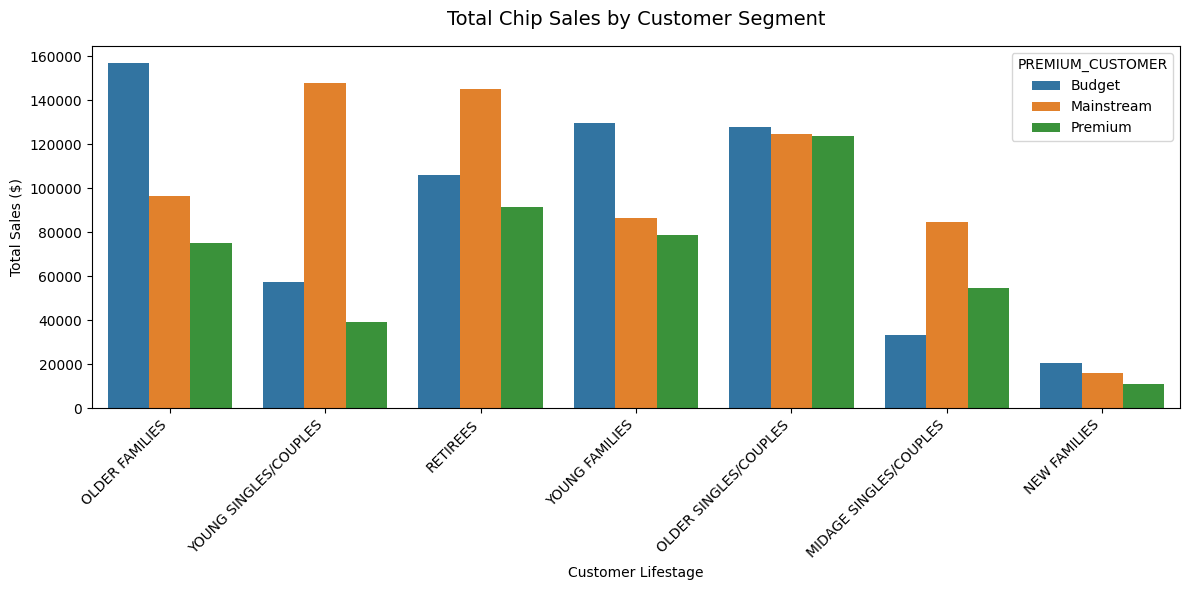

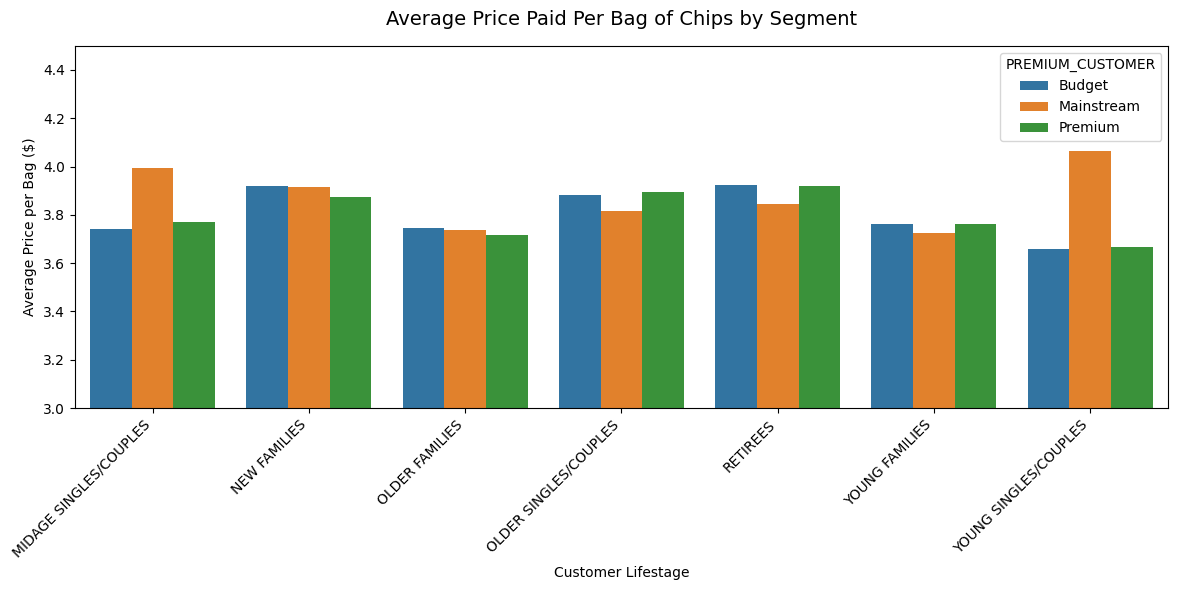

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Data Analysis for Julia's Report ---\n")

# 1. TOTAL SALES BY CUSTOMER SEGMENT
# Group by Lifestage and Premium category to calculate total revenue
sales_summary = master_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_summary = sales_summary.sort_values(by='TOT_SALES', ascending=False)

print("Top 5 Customer Segments by Total Sales Revenue:")
display(sales_summary.head())

# 2. VISUALIZATION 1: Total Sales Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', errorbar=None)
plt.title('Total Chip Sales by Customer Segment', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Sales ($)')
plt.xlabel('Customer Lifestage')
plt.tight_layout()
plt.show()

# 3. DRIVERS OF SALES: Are they buying more bags, or more expensive bags?
# Calculate Price Per Unit to see who buys premium brands
master_data['PRICE_PER_UNIT'] = master_data['TOT_SALES'] / master_data['PROD_QTY']
price_summary = master_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().reset_index()

# 4. VISUALIZATION 2: Average Price Per Unit
plt.figure(figsize=(12, 6))
sns.barplot(data=price_summary, x='LIFESTAGE', y='PRICE_PER_UNIT', hue='PREMIUM_CUSTOMER', errorbar=None)
plt.title('Average Price Paid Per Bag of Chips by Segment', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price per Bag ($)')
plt.xlabel('Customer Lifestage')
# Adjusting the y-axis limit so the differences are easier to see
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()

--- Deep Dive: Packet Size Preferences ---

Top 5 Preferred Packet Sizes for Mainstream Young Singles/Couples:


,PACK_SIZE_GRAMS,NUMBER_OF_PURCHASES
0,175.0,4997
1,150.0,3080
2,134.0,2315
3,110.0,2051
4,170.0,1575


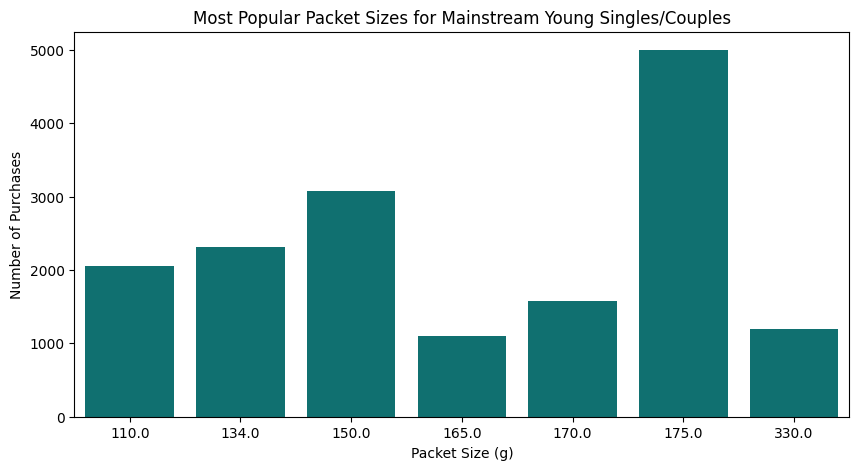

In [ ]:
print("--- Deep Dive: Packet Size Preferences ---\n")

# Filter the data to ONLY look at our target segment
target_segment = master_data[(master_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
                             (master_data['PREMIUM_CUSTOMER'] == 'Mainstream')]

# Count which packet sizes they buy the most
pack_preferences = target_segment['PACK_SIZE'].value_counts().reset_index()
pack_preferences.columns = ['PACK_SIZE_GRAMS', 'NUMBER_OF_PURCHASES']

print("Top 5 Preferred Packet Sizes for Mainstream Young Singles/Couples:")
display(pack_preferences.head())

# Quick Visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=pack_preferences.head(7), x='PACK_SIZE_GRAMS', y='NUMBER_OF_PURCHASES', color='teal')
plt.title('Most Popular Packet Sizes for Mainstream Young Singles/Couples', fontsize=12)
plt.xlabel('Packet Size (g)')
plt.ylabel('Number of Purchases')
plt.show()